In [26]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor


In [27]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/store_sales.csv")

print("\n========== DATASET ==========")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


========== DATASET ==========
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10

Dataset Shape:
(913000, 4)

Columns:
Index(['date', 'store', 'item', 'sales'], dtype='str')

Missing Values:
date     0
store    0
item     0
sales    0
dtype: int64


In [28]:
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values("date")

print("\nDate preprocessing completed.")


Date preprocessing completed.



========== STATISTICS ==========
                             date          store           item          sales
count                      913000  913000.000000  913000.000000  913000.000000
mean   2015-07-02 11:59:59.999999       5.500000      25.500000      52.250287
min           2013-01-01 00:00:00       1.000000       1.000000       0.000000
25%           2014-04-02 00:00:00       3.000000      13.000000      30.000000
50%           2015-07-02 12:00:00       5.500000      25.500000      47.000000
75%           2016-10-01 00:00:00       8.000000      38.000000      70.000000
max           2017-12-31 00:00:00      10.000000      50.000000     231.000000
std                           NaN       2.872283      14.430878      28.801144


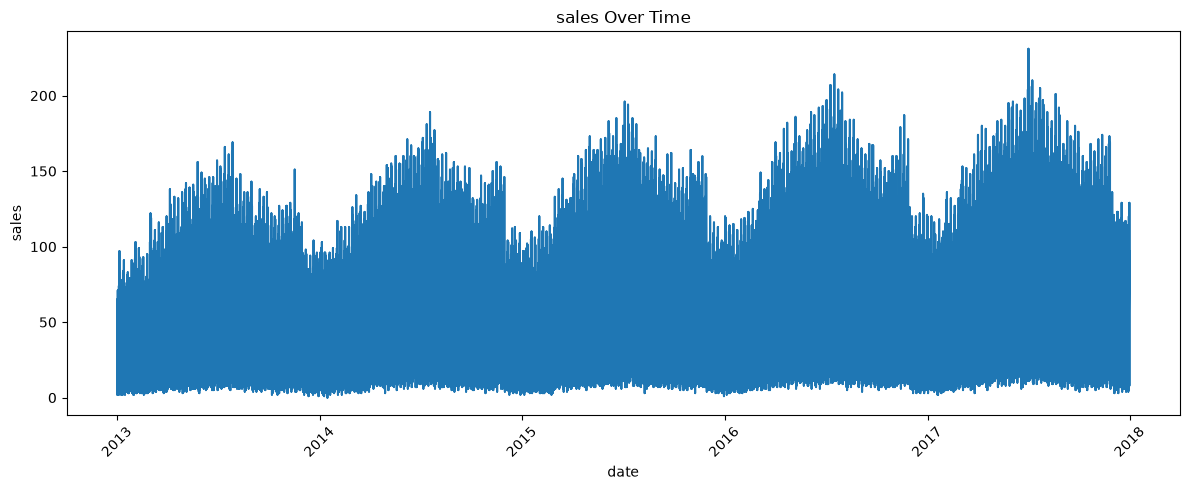

<Axes: xlabel='sales', ylabel='Count'>

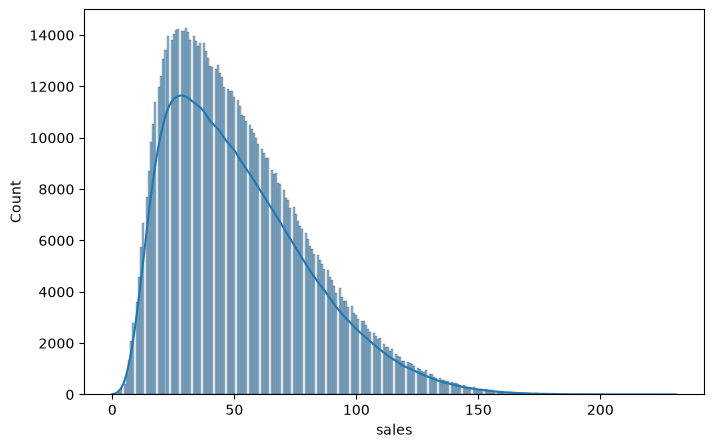

In [29]:
print("\n========== STATISTICS ==========")
print(df.describe())




# Sales over time
plt.figure(figsize=(12, 5))

plt.plot(
    df["date"],
    df["sales"]
)

plt.xlabel("date")
plt.ylabel("sales")
plt.title("sales Over Time")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


# Sales distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    df["sales"],
    kde=True
)

In [30]:
df["Year"] = df["date"].dt.year

df["Month"] = df["date"].dt.month

df["Day"] = df["date"].dt.day

df["DayOfWeek"] = df["date"].dt.dayofweek

df["WeekOfYear"] = df["date"].dt.isocalendar().week.astype(int)


In [31]:
df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)







print("\n========== FEATURES ==========")

print(df.head())



========== FEATURES ==========
             date  store  item  sales  Year  Month  Day  DayOfWeek  \
0      2013-01-01      1     1     13  2013      1    1          1   
211816 2013-01-01      7    12     26  2013      1    1          1   
832656 2013-01-01      7    46     27  2013      1    1          1   
213642 2013-01-01      8    12     54  2013      1    1          1   
215468 2013-01-01      9    12     35  2013      1    1          1   

        WeekOfYear  IsWeekend  
0                1          0  
211816           1          0  
832656           1          0  
213642           1          0  
215468           1          0  


In [32]:
features = [
    "store",
    "item",
    "Year",
    "Month",
    "Day",
    "DayOfWeek"
    
]

X = df[features]

y = df["sales"]


print("\nX shape:", X.shape)

print("y shape:", y.shape)


X shape: (913000, 6)
y shape: (913000,)


In [33]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]


print("\n========== TRAIN TEST ==========")

print("X_train:", X_train.shape)

print("X_test :", X_test.shape)

print("y_train:", y_train.shape)

print("y_test :", y_test.shape)



========== TRAIN TEST ==========
X_train: (730400, 6)
X_test : (182600, 6)
y_train: (730400,)
y_test : (182600,)


In [34]:

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

In [35]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=2
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)


In [36]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

In [37]:
def evaluate_model(name, y_test, prediction):

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    mse = mean_squared_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        prediction
    )

    print("\n==============================")

    print(name)

    print("==============================")

    print("MAE :", mae)

    print("RMSE:", rmse)

    print("R2  :", r2)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [38]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

xgb_results = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)


Linear Regression
MAE : 25.06873729144279
RMSE: 30.64070446680585
R2  : 0.05674446335349337

Random Forest
MAE : 10.891072363754102
RMSE: 16.31491937511879
R2  : 0.7325751660069781

XGBoost
MAE : 7.3044891357421875
RMSE: 9.940830272484671
R2  : 0.9007164835929871


In [39]:
results = {
    "Linear Regression": linear_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
}


best_model_name = min(
    results,
    key=lambda x: results[x]["RMSE"]
)


print("\n================================")
print("BEST MODEL:", best_model_name)
print("================================")


BEST MODEL: XGBoost


In [40]:
if best_model_name == "Linear Regression":

    best_model = linear_model

elif best_model_name == "Random Forest":

    best_model = rf_model

else:

    best_model = xgb_model



In [41]:
with open("model.pkl", "wb") as file:

    pickle.dump(
        best_model,
        file
    )



In [42]:
with open("features.pkl", "wb") as file:

    pickle.dump(
        features,
        file
    )


print("\nModel saved successfully!")

print("model.pkl")
print("product_encoder.pkl")
print("features.pkl")


Model saved successfully!
model.pkl
product_encoder.pkl
features.pkl
